# 基于ResNet模型实现猫狗分类

从 VGG11 到 VGG19，不同之处仅在于网络层数，一般来说，神经网络越深，它的准确率就越高。但并非仅增加网络层数，就可以获得更准确的结果，随着网络层数的增加可能会出现以下问题：  
- 梯度消失和爆炸：在网络层次过深的情况下，反向传播可能会面临梯度消失和爆炸的问题，导致训练网络时无法收敛  
- 过拟合：增加网络深度会带来更多的参数，如果数据样本过少或网络过于复杂，会导致网络过拟合，降低模型的泛化能力

总之，在构建的神经网络过深时，有两个问题：前向传播中，网络的最后几层几乎没有学习到有关原始图像的任何信息；在反向传播中，由于梯度消失(梯度值几乎为零)，靠近输入的前几层几乎没有任何梯度更新。  
 
深度残差网络 (ResNet) 的提出就是为了解决上述问题。在 ResNet 中，如果模型没有什么要学习的，那么卷积层可以什么也不做，只是将上一层的输出传递给下一层。但是，如果模型需要学习其他一些特征，则卷积层将前一层的输出作为输入，并学习完成目标任务所需的其它特征。

## 1. ResNet架构

ResNet 通过残差结构解决网络过深时出现的问题，让模型能够训练得更深。经典的 ResNet 架构如下所示：

![15.1](../Images/15.1.png)

1. 34-layer residual (ResNet-34)  
这是一个带残差连接的 34 层深度残差网络。  
- 核心创新：引入了残差块（Residual Block），通过跳跃连接（图中的黑色曲线）将输入直接加到卷积层的输出上，解决了深度网络训练时的梯度消失问题。  
- 结构特点：  
    - 输入图像经过一个 7×7 卷积和池化层后，进入由多个残差块组成的四个主要阶段。  
    - 每个阶段包含多个 3×3 卷积层，通道数分别为 64、128、256、512。  
    - 虚线连接表示当输入和输出通道数或尺寸不匹配时，残差连接会通过 1×1 卷积进行维度调整。 
    - 最后通过全局平均池化和全连接层输出分类结果。  

2. 34-layer plain (Plain-34)  
这是与 ResNet-34 层数相同，但没有残差连接的普通卷积网络。  
- 结构特点：
    - 网络结构与 ResNet-34 几乎完全一致，同样由四个阶段的卷积层堆叠而成。
    - 关键区别在于没有跳跃连接，信息只能逐层传递。
- 训练问题：在实际训练中，这个 34 层的普通网络性能会比 18 层的网络更差，因为深度增加导致梯度消失，模型难以收敛。

3. VGG-19
这是一个经典的 19 层卷积神经网络，以其规整的结构著称。
- 结构特点：
    - 所有卷积层都使用 3×3 的卷积核，通过堆叠多个小卷积核来模拟大卷积核的感受野。
    - 网络分为五个阶段，每个阶段后接一个池化层，逐步降低特征图尺寸，同时增加通道数（64 → 128 → 256 → 512 → 512）。
    - 最后通过三个全连接层输出分类结果，这导致了参数量巨大（约 1.38 亿）。

残差结构的基本思想是：每一个残差块都不是直接映射输入信号到输出信号，而是通过学习残差映射来实现：

$$
F(x) = H(x) - x
$$

其中，$x$ 是输入，$H(x)$ 是一个表示所需映射的基本块，而 $F(x)$ 是残差块学习到的映射。换句话说，输入 $x$ 通过卷积层，得到特征变换后的输出 $F(x)$，与输入 $x$ 进行逐元素的相加运算，得到最终输出 $H(x)$：

$$
H(x) = x + F(x)
$$

如果某个基本块为恒等映射，则残差块的学习目标就变为学习 $ F ( x ) = 0 $ ，也就是让输入信号直接到达残差块的输出层。这样就可以解决梯度消失的问题，可以训练更深的神经网络。

实现过程中 ResNet 中使用 Shortcut Connection (也称跳跃连接, Skip Connection )在残差块中实现跨层连接，从而实现信息的直接传递，跨层连接可以绕过一个或多个卷积层，直接将网络中的浅层信息传递到深层中。

在 ResNet 的残差块中，Shortcut Connection 经常与卷积层或批归一化 (Batch Normalization) 相结合。通过该连接，残差块的激活张量可以直接和下一层的输出相加，理论上，即使是最后一层可能拥有原始图像的全部信息，并且反向传播过程中梯度将可以在几乎没有修改的情况下自由地流向浅层。典型的残差块如下所示：

![15.2](../Images/15.2.png)

在传统中顺序堆叠的神经网络中，神经网络通常直接学习 $ F ( x ) $ ，其中 $x$ 是来自前一层的输出值，而在残差网络中，利用跳跃连接，将残差信号 $F ( x )$ 加上恒等映射 $x$ 得到最终的输出 $H ( x ) = F ( x ) + x$ 。接下来，我们通过在 PyTorch 中构建残差块来深入了解残差网络。

## 2. 基于预训练ResNet模型实现猫狗分类  
1. 在init方法中定义一个带有卷积操作的类：

In [1]:
from torch import nn

class ResLayer(nn.Module):
    def __init__(self,ni,no,kernel_size,stride=1):
        super(ResLayer, self).__init__()
        padding = kernel_size - 2
        self.conv = nn.Sequential(
            nn.Conv2d(ni, no, kernel_size, stride, padding),
            nn.ReLU()
        )

在以上代码中，为了确保通过卷积后输出的尺寸保持不变，以便于将输入与卷结果相加，我们通过 padding 控制卷积时输出的尺寸。

2. 定义forward方法：

In [ ]:
def forward(self, x):
    return self.conv(x) + x

在以上代码中，得到的输出是通过卷积操作的输入和原始输入之和。

在 PyTorch 中预训练的基于残差块的 ResNet18 架构如下：  
![15.3](../Images/15.3.png)

该架构有 18 个可训练网络层，因此被称为 ResNet18 架构。此外，需要注意的是，ResNet18 并不是每个卷积层都会添加跳跃连接，而是在每两层之后使用跳跃连接。  
​
了解了 ResNet 架构之后，构建一个基于预训练 ResNet18 架构的模型来执行狗猫分类任务。构建分类器的流程可以参考在[迁移学习中使用预训练 VGG16 模型构建的猫狗分类器](14.迁移学习.ipynb)。

3. 加载预训练 ResNet18 模型并检查模型中的模块：

In [ ]:
import torchvision.models as models
model = models.resnet18(pretrained=True) 

e:\Users\Admin\anaconda3\envs\new_pytorch\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Users\Admin\anaconda3\envs\new_pytorch\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


4. 定义模型架构、损失函数和优化器：

In [ ]:
device = "cpu"
def get_model():
    model = models.resnet18(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    model.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, 218),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(218, 1),
        nn.Sigmoid()
    )
    loss_fn = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    return model.to(device), loss_fn, optimizer

在模型中，fc 模块的输入形状为 512，因为 avgpool 的输出形状为 batch size x 512 x 1 x 1。定义了模型后，训练模型，随着 epoch 的增加，模型训练和验证准确率的变化(对应模型分别为 ResNet18、ResNet34、ResNet50和ResNet101) 如下：

Epoch 1/10
Train Loss: 0.2158
Train Acc : 0.9268
Val Acc   : 0.9619
------------------------------
Epoch 2/10
Train Loss: 0.1175
Train Acc : 0.9502
Val Acc   : 0.9580
------------------------------
Epoch 3/10
Train Loss: 0.1279
Train Acc : 0.9375
Val Acc   : 0.9482
------------------------------
Epoch 4/10
Train Loss: 0.1061
Train Acc : 0.9600
Val Acc   : 0.9785
------------------------------
Epoch 5/10
Train Loss: 0.0831
Train Acc : 0.9668
Val Acc   : 0.9746
------------------------------
Epoch 6/10
Train Loss: 0.0693
Train Acc : 0.9746
Val Acc   : 0.9639
------------------------------
Epoch 7/10
Train Loss: 0.0481
Train Acc : 0.9834
Val Acc   : 0.9688
------------------------------
Epoch 8/10
Train Loss: 0.0508
Train Acc : 0.9795
Val Acc   : 0.9756
------------------------------
Epoch 9/10
Train Loss: 0.0494
Train Acc : 0.9824
Val Acc   : 0.9717
------------------------------
Epoch 10/10
Train Loss: 0.0505
Train Acc : 0.9795
Val Acc   : 0.9775
------------------------------


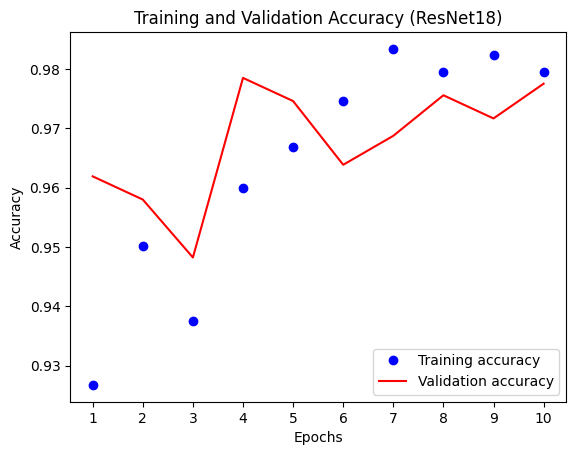

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import os
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cpu")

# 数据集
class CatsDogs(Dataset):
    def __init__(self, folder):
        dogs = glob(os.path.join(folder, 'dogs', '*.jpg'))
        cats = glob(os.path.join(folder, 'cats', '*.jpg'))

        self.fpaths = cats[:500] + dogs[:500]

        from random import shuffle, seed
        seed(10)
        shuffle(self.fpaths)

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        self.targets = [
            1 if os.path.basename(f).startswith('dog') else 0
            for f in self.fpaths
        ]

    def __len__(self):
        return len(self.fpaths)

    def __getitem__(self, ix):
        f = self.fpaths[ix]
        y = self.targets[ix]

        im = cv2.imread(f)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        im = cv2.resize(im, (224, 224))

        im = torch.tensor(im / 255.).permute(2, 0, 1)
        im = self.normalize(im)

        return im.float().to(device), torch.tensor([y]).float().to(device)


# 模型定义
def get_model():
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    model.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, 218),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(218, 1),
        nn.Sigmoid()
    )

    model = model.to(device)

    loss_fn = nn.BCELoss()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

    return model, loss_fn, optimizer


# 训练&验证函数
def train_epoch(model, dataloader, optimizer, loss_fn):
    model.train()
    epoch_losses = []
    epoch_acc = []

    for x, y in dataloader:
        prediction = model(x)
        loss = loss_fn(prediction, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

        preds = (prediction > 0.5).float()
        acc = (preds == y).float().mean().item()
        epoch_acc.append(acc)

    return np.mean(epoch_losses), np.mean(epoch_acc)


@torch.no_grad()
def validate_epoch(model, dataloader):
    model.eval()
    epoch_acc = []

    for x, y in dataloader:
        prediction = model(x)
        preds = (prediction > 0.5).float()
        acc = (preds == y).float().mean().item()
        epoch_acc.append(acc)

    return np.mean(epoch_acc)


# 数据加载
train_data_dir = r'E:\pwr\leaning\Start-with-Pytorch\data\cat&dog\training_set\training_set'
test_data_dir  = r'E:\pwr\leaning\Start-with-Pytorch\data\cat&dog\test_set\test_set'

train_ds = CatsDogs(train_data_dir)
val_ds = CatsDogs(test_data_dir)

trn_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)


# 初始化模型
model, loss_fn, optimizer = get_model()


# 训练循环
epochs = 10
train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, trn_dl, optimizer, loss_fn)
    val_acc = validate_epoch(model, val_dl)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")
    print("-" * 30)


# 可视化
epochs_range = np.arange(epochs) + 1

plt.figure()
plt.plot(epochs_range, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and Validation Accuracy (ResNet18)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


![15.4](../Images/15.4.png)  
![15.5](../Images/15.5.png)  
![15.6]([../Images/15.6.png](https://github.com/pengwanru62-lang/Start-with-Pytorch/blob/main/Images/15.6.png))  
仅对1000张图像进行训练时，模型的准确率就可以达到98%左右，并且准确率随着ResNet层数的增加而增加

## 小结
本节学习了ResNet相关概念，并且使用ResNet模型实现了猫狗分类